# Task 3: Fraud Detection

## Objective
Build a machine learning pipeline to detect fraudulent financial transactions from a highly imbalanced credit card transaction dataset.

### Main Tasks
- Analyze class imbalance
- Perform exploratory data analysis
- Explain why accuracy is misleading
- Apply SMOTE to address class imbalance
- Train Logistic Regression and Random Forest models
- Evaluate Precision, Recall, F1-Score and ROC-AUC
- Analyze the Recall vs Precision trade-off
- Examine feature importance
- Discuss model scalability

In [1]:
import sys
print(sys.executable)

c:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Fraud Detection\.venv\Scripts\python.exe


In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    auc
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Dataset

The dataset contains credit card transactions from European cardholders. The target variable is `Class`, where `0` represents a legitimate transaction and `1` represents a fraudulent transaction.

In [3]:
DATA_PATH = r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Fraud Detection\data\creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Dataset Structure

The dataset contains:
- `Time`: seconds elapsed between the transaction and the first transaction
- `Amount`: transaction amount
- `V1` to `V28`: anonymized PCA-transformed features
- `Class`: target variable, where 0 = legitimate and 1 = fraud

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -

### Missing Value Check

Before modelling, missing values are checked because machine learning algorithms require clean numerical input.

In [5]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081


## 3. Descriptive Statistics

Descriptive statistics help us understand the numerical characteristics of the transaction data.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 4. Class Imbalance Analysis

Fraud detection is a highly imbalanced binary classification problem. The majority class represents legitimate transactions, while fraudulent transactions form a very small minority.

The percentage of fraudulent transactions is calculated below.

In [8]:
class_counts = df["Class"].value_counts().sort_index()

print("Class counts:")
print(class_counts)

fraud_percentage = (df["Class"].mean()) * 100

print(f"\nFraudulent transactions: {class_counts[1]:,}")
print(f"Legitimate transactions: {class_counts[0]:,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")
print(f"Legitimate percentage: {100 - fraud_percentage:.4f}%")

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Fraudulent transactions: 492
Legitimate transactions: 284,315
Fraud percentage: 0.1727%
Legitimate percentage: 99.8273%


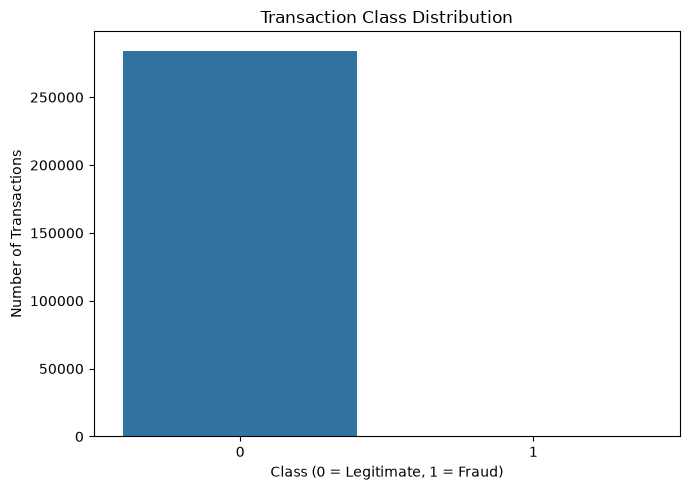

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=300)
plt.show()

### Observation

The dataset is extremely imbalanced. Fraudulent transactions represent only about 0.17% of all transactions, while legitimate transactions represent about 99.83%.

This means a model can obtain very high accuracy simply by predicting almost every transaction as legitimate while still failing to detect many fraudulent transactions.

## 5. Why Accuracy Is Misleading

Because fraudulent transactions are extremely rare, accuracy alone is not sufficient for evaluating a fraud detection model.

For example, a classifier that predicts every transaction as legitimate can achieve approximately 99.83% accuracy, even though it detects zero fraudulent transactions.

In [10]:
dummy = DummyClassifier(strategy="most_frequent")

X_dummy = df.drop(columns=["Class"])
y_dummy = df["Class"]

dummy.fit(X_dummy, y_dummy)

dummy_predictions = dummy.predict(X_dummy)

dummy_accuracy = accuracy_score(y_dummy, dummy_predictions)

print(f"Majority-class baseline accuracy: {dummy_accuracy:.4%}")
print("Fraud cases detected:", dummy_predictions[y_dummy == 1].sum())

Majority-class baseline accuracy: 99.8273%
Fraud cases detected: 0


## 6. Exploratory Data Analysis

### Transaction Amount: Fraud vs Non-Fraud

The distribution of transaction amounts is examined separately for fraudulent and legitimate transactions.

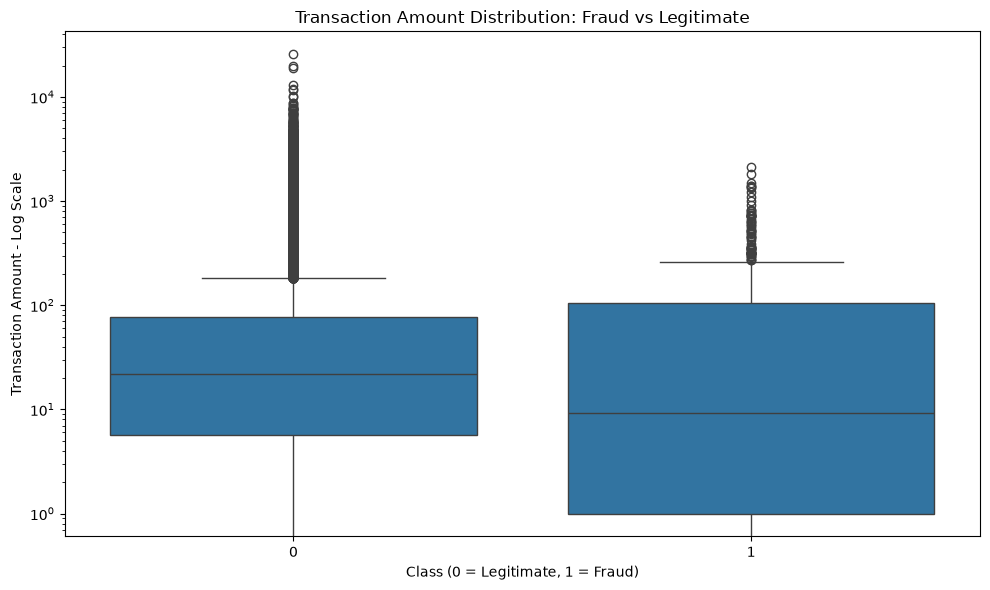

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount - Log Scale")

plt.tight_layout()
plt.savefig("../images/amount_distribution.png", dpi=300)
plt.show()

In [12]:
amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

amount_summary

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


### Time-of-Day Analysis

The `Time` feature represents seconds elapsed from the first transaction. It is converted into an approximate hour of day using a 24-hour cycle to investigate whether fraudulent transactions show different time-of-day patterns.

In [13]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

hourly_fraud = (
    df.groupby("Hour")["Class"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "fraud_count"})
)

hourly_fraud["fraud_rate"] = (
    hourly_fraud["fraud_count"] / hourly_fraud["count"] * 100
)

hourly_fraud

,count,fraud_count,fraud_rate
Hour,,,
0,7695,6,0.077973
1,4220,10,0.236967
2,3328,57,1.712740
3,3492,17,0.486827
4,2209,23,1.041195
5,2990,11,0.367893
6,4101,9,0.219459
7,7243,23,0.317548
8,10276,9,0.087583


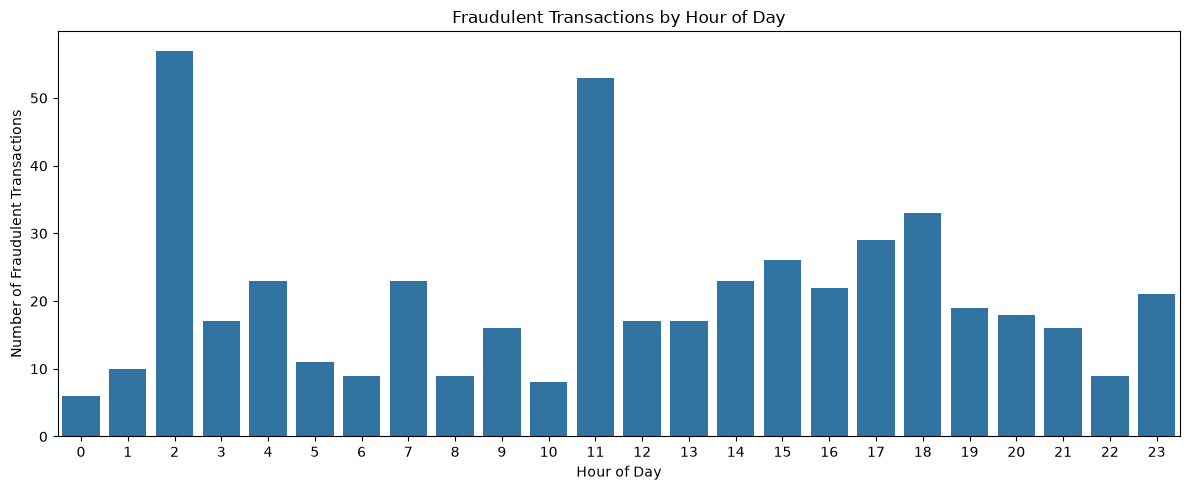

In [14]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=hourly_fraud.reset_index(),
    x="Hour",
    y="fraud_count"
)

plt.title("Fraudulent Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")

plt.tight_layout()
plt.savefig("../images/time_of_day.png", dpi=300)
plt.show()

### Observation

Fraud occurrence varies across the derived hours of the day. However, the dataset covers only two days and the `Time` feature is anonymized, so the observed hourly pattern should be treated as dataset-specific rather than a general rule about real-world fraud.

## 7. Feature and Target Separation

`Class` is the target variable. All remaining original transaction features are used as predictors.

In [15]:
model_df = df.drop(columns=["Hour"])

X = model_df.drop(columns=["Class"])
y = model_df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## 8. Stratified Train-Test Split

The dataset is split into training and testing sets using stratification. Stratification preserves approximately the same class proportions in both sets, ensuring that fraudulent transactions appear in both the training and testing data.

The test set remains untouched during SMOTE and model training.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (227845, 30)
Testing set: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [17]:
print("Fraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

assert y_train.sum() > 0
assert y_test.sum() > 0

print("\nStratification check passed.")

Fraud cases in training set: 394
Fraud cases in testing set: 98

Stratification check passed.


## 9. Handling Class Imbalance Using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class samples to increase representation of the fraud class.

SMOTE is applied only inside the training pipeline. The test set is not resampled because it must represent unseen real-world data.

The pipeline order is:

1. Standardize features
2. Apply SMOTE to training data
3. Train the classifier

In [18]:
print("Before SMOTE:")
print(Counter(y_train))

Before SMOTE:
Counter({0: 227451, 1: 394})


## 10. Model 1 — Logistic Regression

Logistic Regression provides a simple and interpretable linear classification baseline.

The pipeline uses:
- StandardScaler
- SMOTE
- Logistic Regression

In [19]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(
        random_state=RANDOM_STATE,
        sampling_strategy="auto"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

print(lr_model)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [20]:
start_time = time.perf_counter()

lr_model.fit(X_train, y_train)

lr_training_time = time.perf_counter() - start_time

print(f"Logistic Regression training time: {lr_training_time:.2f} seconds")

Logistic Regression training time: 1.46 seconds


In [21]:
lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression predictions generated.")

Logistic Regression predictions generated.


In [22]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, zero_division=0)
lr_recall = recall_score(y_test, lr_predictions, zero_division=0)
lr_f1 = f1_score(y_test, lr_predictions, zero_division=0)
lr_roc_auc = roc_auc_score(y_test, lr_probabilities)

print("Logistic Regression")
print("----------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

Logistic Regression
----------------------------
Accuracy : 0.9741
Precision: 0.0578
Recall   : 0.9184
F1-Score : 0.1088
ROC-AUC  : 0.9708


In [23]:
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9999    0.9742    0.9869     56864
       Fraud     0.0578    0.9184    0.1088        98

    accuracy                         0.9741     56962
   macro avg     0.5288    0.9463    0.5478     56962
weighted avg     0.9982    0.9741    0.9854     56962



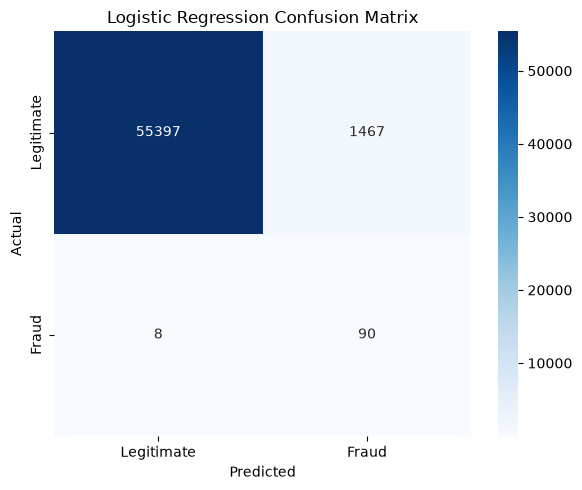

In [24]:
lr_cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/confusion_matrix_lr.png", dpi=300)
plt.show()

## 11. Model 2 — Random Forest

Random Forest is an ensemble model that combines multiple decision trees.

It can capture nonlinear relationships between the transaction features and fraud class.

The same SMOTE-based training pipeline is used.

In [25]:
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(
        random_state=RANDOM_STATE,
        sampling_strategy="auto"
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print(rf_model)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=2, n_jobs=-1,
                                        random_state=42))])


In [26]:
start_time = time.perf_counter()

rf_model.fit(X_train, y_train)

rf_training_time = time.perf_counter() - start_time

print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training time: 46.37 seconds


In [27]:
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [28]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, zero_division=0)
rf_recall = recall_score(y_test, rf_predictions, zero_division=0)
rf_f1 = f1_score(y_test, rf_predictions, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest")
print("----------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest
----------------------------
Accuracy : 0.9994
Precision: 0.8421
Recall   : 0.8163
F1-Score : 0.8290
ROC-AUC  : 0.9720


In [29]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9997    0.9997    0.9997     56864
       Fraud     0.8421    0.8163    0.8290        98

    accuracy                         0.9994     56962
   macro avg     0.9209    0.9080    0.9144     56962
weighted avg     0.9994    0.9994    0.9994     56962



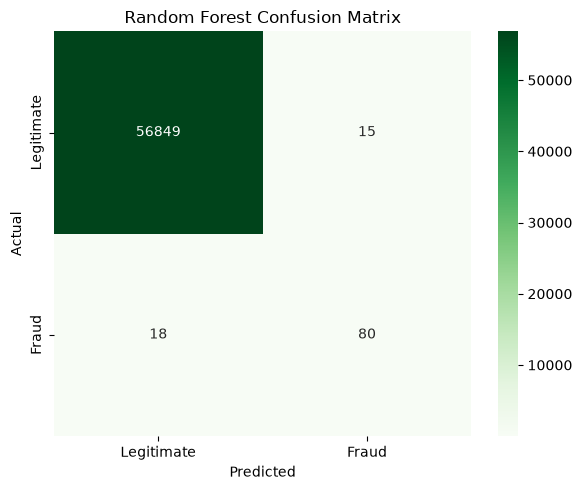

In [30]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/confusion_matrix_rf.png", dpi=300)
plt.show()

## 12. Model Comparison

The models are compared using metrics that are more informative for imbalanced fraud detection than accuracy alone.

In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ],
    "Training Time (seconds)": [
        lr_training_time,
        rf_training_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (seconds)
0,Logistic Regression,0.974106,0.057803,0.918367,0.108761,0.970843,1.458664
1,Random Forest,0.999421,0.842105,0.816327,0.829016,0.971969,46.365508


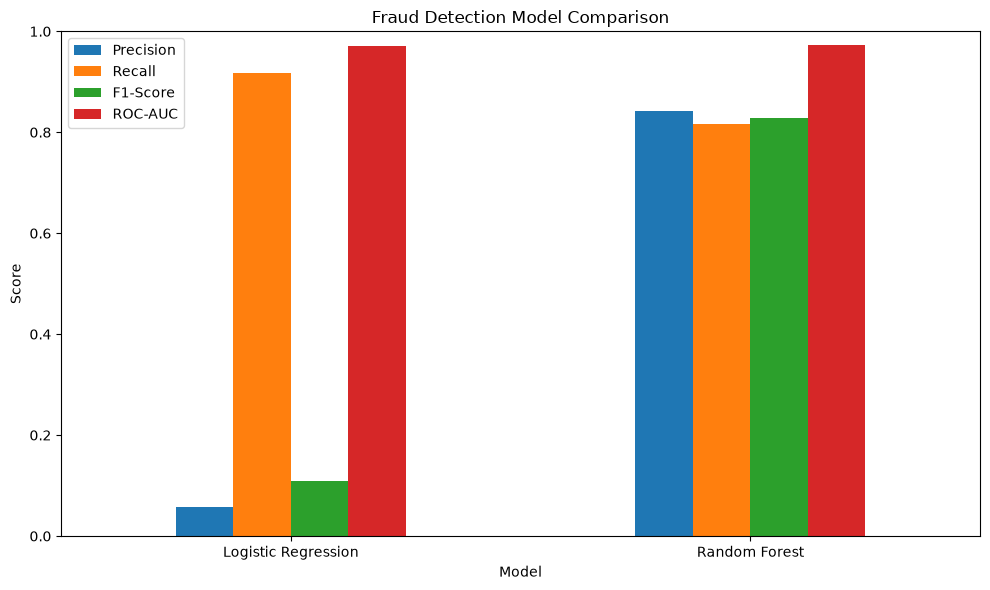

In [32]:
metric_plot = results.set_index("Model")[
    ["Precision", "Recall", "F1-Score", "ROC-AUC"]
]

metric_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 13. Which Metric Matters Most for Fraud Detection?

For fraud detection, **Recall for the fraud class** is especially important when the cost of missing a fraudulent transaction is high.

### Recall
Recall measures the proportion of actual fraudulent transactions that were successfully detected.

A low fraud recall means many fraudulent transactions are missed.

### Precision
Precision measures how many transactions predicted as fraud are actually fraudulent.

A low precision means many legitimate customers may be incorrectly flagged.

### Recall vs Precision Trade-off

Increasing recall generally makes the model more sensitive to possible fraud, but it can also increase false positives and reduce precision.

Therefore, the appropriate operating point depends on the relative costs of:
- False negatives: fraudulent transactions missed
- False positives: legitimate transactions incorrectly flagged

F1-score combines precision and recall into a single measure and is useful when both types of error matter.

ROC-AUC measures ranking ability across classification thresholds, but for highly imbalanced fraud detection, precision-recall behavior should also be considered.

## 14. ROC-AUC Curve

The ROC curve evaluates the relationship between the true positive rate and false positive rate across different classification thresholds.

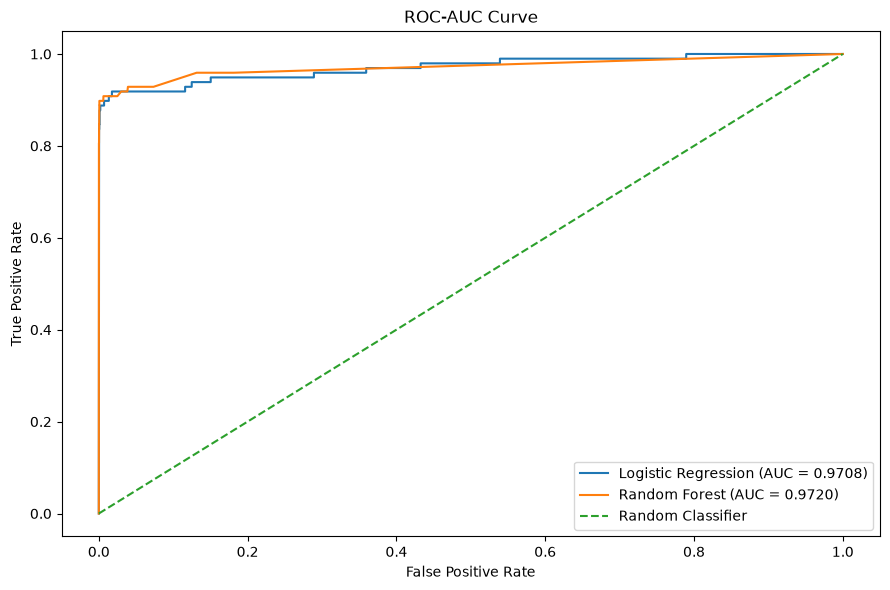

In [33]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(9, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=300)
plt.show()

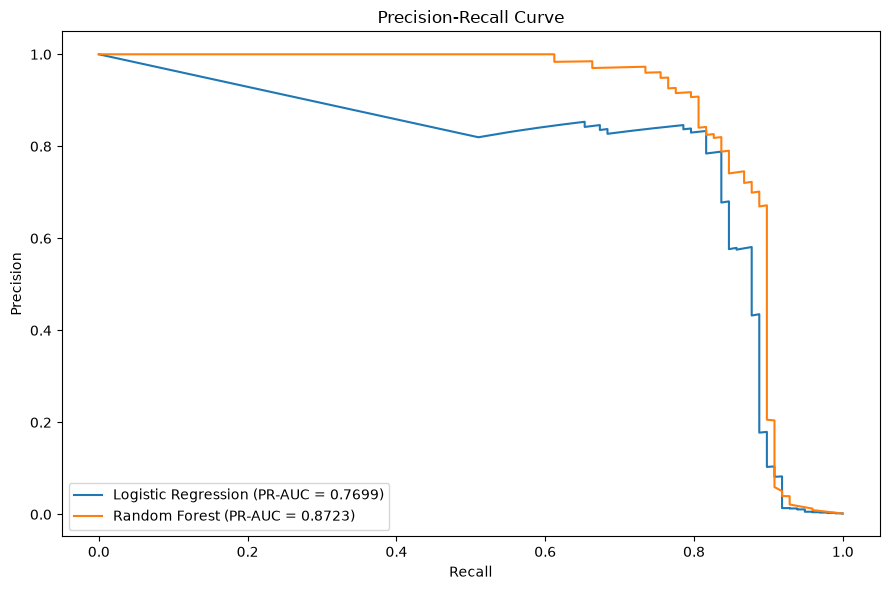

In [34]:
lr_precision_curve, lr_recall_curve, _ = precision_recall_curve(
    y_test,
    lr_probabilities
)

rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(
    y_test,
    rf_probabilities
)

lr_pr_auc = auc(lr_recall_curve, lr_precision_curve)
rf_pr_auc = auc(rf_recall_curve, rf_precision_curve)

plt.figure(figsize=(9, 6))

plt.plot(
    lr_recall_curve,
    lr_precision_curve,
    label=f"Logistic Regression (PR-AUC = {lr_pr_auc:.4f})"
)

plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Random Forest (PR-AUC = {rf_pr_auc:.4f})"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

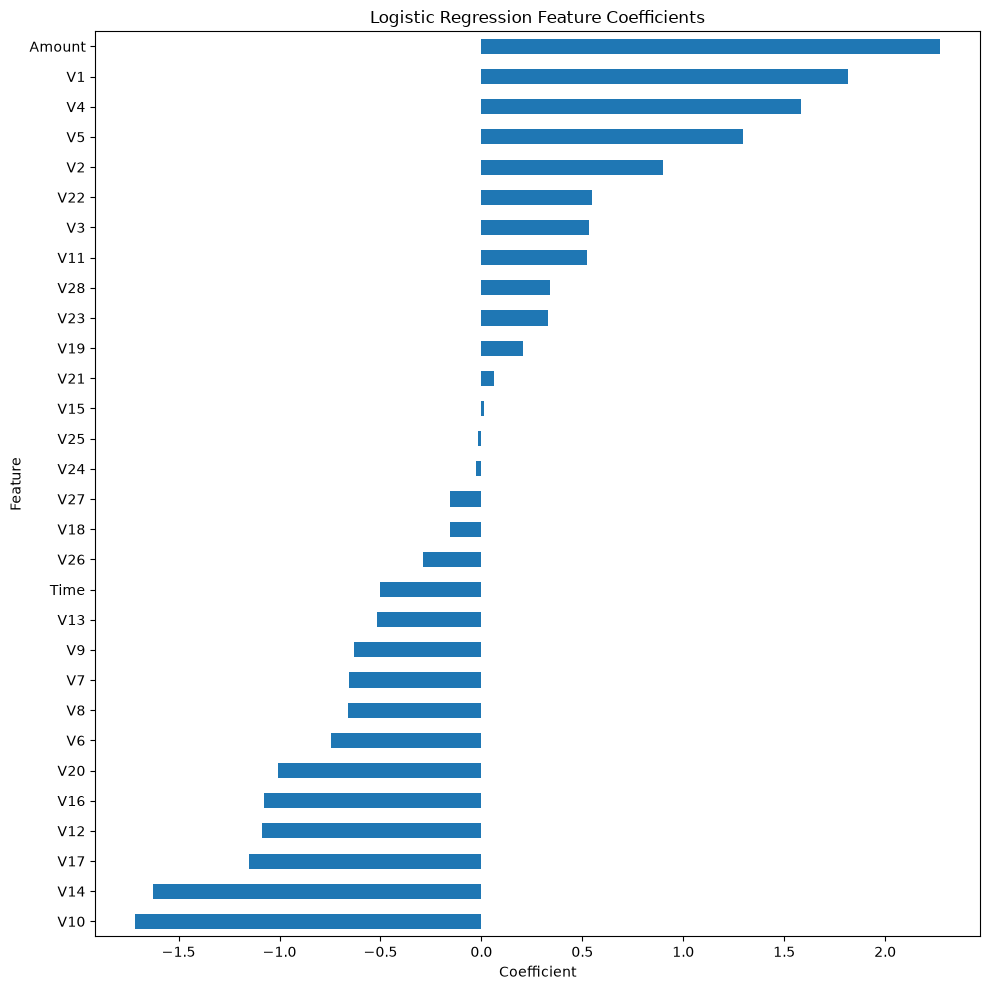

In [35]:
lr_coefficients = pd.Series(
    lr_model.named_steps["classifier"].coef_[0],
    index=X_train.columns
)

lr_coefficients = lr_coefficients.sort_values()

plt.figure(figsize=(10, 10))

lr_coefficients.plot(kind="barh")

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [36]:
rf_importance = pd.Series(
    rf_model.named_steps["classifier"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(rf_importance.head(15))

V14    0.197866
V10    0.109978
V4     0.107217
V12    0.096159
V17    0.085322
V3     0.062915
V11    0.052611
V16    0.044360
V2     0.037520
V9     0.026216
V7     0.016446
V21    0.015332
V8     0.014709
V18    0.013312
V19    0.011222
dtype: float64


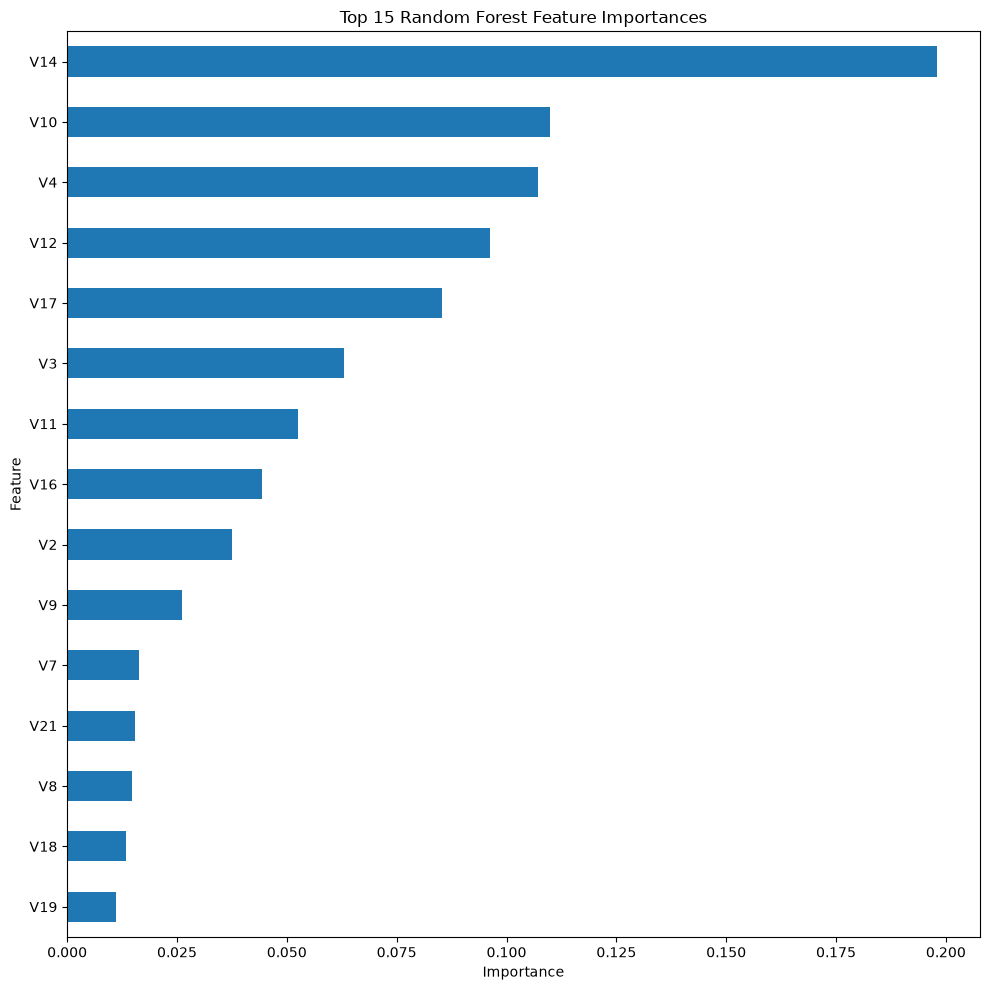

In [37]:
plt.figure(figsize=(10, 10))

rf_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300)
plt.show()

### Feature Importance Observation

The Random Forest feature importance values indicate which anonymized transaction features contribute most strongly to the model's decision process.

The `V1`–`V28` variables are anonymized PCA-derived features, so their names do not have direct business interpretations. Therefore, feature importance identifies predictive variables but does not reveal the original financial meaning of those variables.

## 15. Scalability Analysis

A production fraud detection system may need to process very large transaction volumes.

One million transactions per hour corresponds to approximately 278 transactions per second.

The prediction throughput of the trained models is benchmarked below. This measures inference speed on the current machine and should be treated as a local benchmark rather than a production capacity guarantee.

In [38]:
benchmark_size = min(50000, len(X_test))

X_benchmark = X_test.iloc[:benchmark_size]

print("Benchmark transactions:", benchmark_size)

Benchmark transactions: 50000


In [39]:
start = time.perf_counter()

_ = lr_model.predict_proba(X_benchmark)

lr_prediction_time = time.perf_counter() - start

lr_tps = benchmark_size / lr_prediction_time

print(f"Logistic Regression:")
print(f"Time: {lr_prediction_time:.4f} seconds")
print(f"Transactions/second: {lr_tps:,.2f}")
print(f"Estimated transactions/hour: {lr_tps * 3600:,.0f}")

Logistic Regression:
Time: 0.0214 seconds
Transactions/second: 2,334,310.63
Estimated transactions/hour: 8,403,518,272


In [40]:
start = time.perf_counter()

_ = lr_model.predict_proba(X_benchmark)

lr_prediction_time = time.perf_counter() - start

lr_tps = benchmark_size / lr_prediction_time

print(f"Logistic Regression:")
print(f"Time: {lr_prediction_time:.4f} seconds")
print(f"Transactions/second: {lr_tps:,.2f}")
print(f"Estimated transactions/hour: {lr_tps * 3600:,.0f}")

Logistic Regression:
Time: 0.0340 seconds
Transactions/second: 1,468,817.01
Estimated transactions/hour: 5,287,741,253


In [41]:
required_tps = 1_000_000 / 3600

print(f"Required throughput: {required_tps:.2f} transactions/second")

Required throughput: 277.78 transactions/second


In [42]:
# Measure Random Forest prediction throughput

rf_start = time.time()

rf_predictions = rf_model.predict(X_test)

rf_end = time.time()

rf_elapsed = rf_end - rf_start

rf_tps = len(X_test) / rf_elapsed

print("Random Forest prediction time:", rf_elapsed, "seconds")
print("Random Forest throughput:", rf_tps, "transactions/second")
print("Random Forest throughput per hour:", rf_tps * 3600)

Random Forest prediction time: 0.15632247924804688 seconds
Random Forest throughput: 364387.7724688255 transactions/second
Random Forest throughput per hour: 1311795980.8877718


In [43]:
print("Logistic Regression meets 1M/hour benchmark:",
      lr_tps >= required_tps)

print("Random Forest meets 1M/hour benchmark:",
      rf_tps >= required_tps)

Logistic Regression meets 1M/hour benchmark: True
Random Forest meets 1M/hour benchmark: True


### Scalability Discussion

Processing one million transactions per hour requires approximately 278 transactions per second.

The local benchmark provides an estimate of model inference throughput on the current computer.

For a real production system, scalability would involve:

- Batch prediction where possible
- Parallel inference
- Multiple model-serving workers
- Horizontal scaling across multiple servers
- Efficient feature preprocessing
- Low-latency data pipelines
- Monitoring of prediction latency and throughput
- Periodic model retraining as fraud patterns change

Logistic Regression is computationally lightweight during inference because its prediction involves a relatively small number of numerical operations.

Random Forest requires evaluating multiple decision trees for each transaction, so inference cost generally increases with the number and complexity of trees.

Therefore, whether either model can independently support one million transactions per hour must be determined from the actual benchmark results and production hardware rather than assumed from model type alone.

In [44]:
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_roc_auc, rf_roc_auc],
    "PR-AUC": [lr_pr_auc, rf_pr_auc],
    "Training Time (sec)": [
        lr_training_time,
        rf_training_time
    ],
    "Inference TPS": [
        lr_tps,
        rf_tps
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (sec),Inference TPS
0,Logistic Regression,0.974106,0.057803,0.918367,0.108761,0.970843,0.769946,1.458664,1.468817e+06
1,Random Forest,0.999421,0.842105,0.816327,0.829016,0.971969,0.872301,46.365508,3.643878e+05


## 16. Final Interpretation

The fraud detection problem is strongly affected by class imbalance, with fraudulent transactions representing only a very small fraction of the dataset.

A majority-class classifier can achieve very high accuracy while detecting no fraud, demonstrating why accuracy alone is unsuitable.

SMOTE was therefore applied only to the training data through an imbalanced-learn pipeline, while the test data remained untouched.

Two models were trained:
1. Logistic Regression
2. Random Forest

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Precision-Recall behavior
- Confusion matrices

For fraud detection, fraud-class recall is particularly important when missing fraudulent transactions is costly. Precision must also be considered because excessive false positives can incorrectly flag legitimate transactions.

Feature analysis was performed using Logistic Regression coefficients and Random Forest feature importance.

Finally, prediction throughput was benchmarked against the requirement of approximately 278 transactions per second, which corresponds to one million transactions per hour. The benchmark result is hardware-dependent and should not be treated as a universal production capacity.

## 17. Recommendations

1. Do not use accuracy as the only fraud-detection metric because of extreme class imbalance.

2. Monitor fraud-class recall carefully because missed fraudulent transactions represent false negatives.

3. Monitor precision alongside recall because excessive false positives can affect legitimate customers.

4. Keep SMOTE restricted to the training data to avoid information leakage into the test set.

5. Evaluate models using ROC-AUC and precision-recall behavior rather than relying only on accuracy.

6. Monitor feature importance and model performance over time because fraud patterns can change.

7. For high-volume deployment, benchmark actual inference throughput and use parallel or distributed model serving when required.

8. Retrain the model periodically using recent transaction data and monitor for changes in fraud patterns.

## 18. Project Summary

### Dataset
Credit Card Fraud Detection dataset from Kaggle.

### Dataset Size
284,807 transactions.

### Fraud Cases
492.

### Fraud Rate
Approximately 0.17%.

### Preprocessing
- Missing-value check
- Duplicate check
- Feature-target separation
- Stratified train-test split
- Standardization

### Class Imbalance Technique
SMOTE applied only to the training pipeline.

### Models
- Logistic Regression
- Random Forest

### Evaluation
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Precision-Recall curve
- Confusion matrix

### Explainability
- Logistic Regression coefficients
- Random Forest feature importance

### Scalability
Prediction throughput benchmark against approximately 278 transactions/second, equivalent to one million transactions/hour.